# Mission 2 — Préparation et pipeline sans fuite de données

Cette mission consiste à préparer les données pour la modélisation en respectant
un principe essentiel : aucune transformation apprise à partir des données ne
doit utiliser les informations du jeu de test.

La séparation entre les ensembles d'entraînement et de test sera donc réalisée
avant l'imputation, l'encodage et la standardisation.

Toutes les transformations apprises seront intégrées dans un pipeline
scikit-learn afin de garantir un processus reproductible et sans fuite de données.

## 1. Importation des bibliothèques

Nous importons dans un premier temps les bibliothèques nécessaires au chargement
des données et à leur séparation en ensembles d'entraînement et de test.

Les autres composants nécessaires au preprocessing et à la modélisation seront
introduits progressivement.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import train_test_split

## 2. Chargement des données

Nous rechargeons le dataset original afin que la préparation de la Mission 2
soit indépendante des transformations réalisées pendant l'analyse exploratoire.

Nous repartons donc des données brutes avant de construire le pipeline de
préparation.

In [2]:
DATA_PATH = "../data/raw/Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

df.shape

(7043, 21)

## 3. Correction du type de `TotalCharges`

L'analyse exploratoire de la Mission 1 a montré que `TotalCharges` est
interprétée comme une variable textuelle alors qu'elle représente un montant.

La colonne contient 11 valeurs non numériques correspondant à des espaces.

Nous convertissons donc `TotalCharges` en variable numérique. Les valeurs
non convertibles deviennent des valeurs manquantes (`NaN`).

Cette conversion ne nécessite l'apprentissage d'aucune statistique sur les
données et peut donc être réalisée avant le split. En revanche, les valeurs
manquantes ne sont pas encore imputées.

In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [4]:
print("Type :", df["TotalCharges"].dtype)
print("Valeurs manquantes :", df["TotalCharges"].isna().sum())

Type : float64
Valeurs manquantes : 11


## 4. Définition des variables explicatives et de la cible

Nous séparons les variables explicatives (`X`) de la variable cible (`y`).

La variable `Churn` constitue la cible à prédire.

La variable `customerID` est retirée des variables explicatives, car elle
représente un identifiant unique du client et n'apporte pas une information
généralisable pour la prédiction du churn.

À ce stade, aucune imputation, aucun encodage et aucune standardisation ne sont
effectués.

In [5]:
X = df.drop(
    columns=["customerID", "Churn"]
)

y = df["Churn"]

### 4.1. Vérification de `X` et `y`

Nous vérifions les dimensions des variables explicatives et de la cible avant
de réaliser la séparation train/test.

In [6]:
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

print("\nVariables explicatives :")
print(X.columns.tolist())

Dimensions de X : (7043, 19)
Dimensions de y : (7043,)

Variables explicatives :
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## 5. Séparation train/test stratifiée

Les données sont séparées en deux ensembles :

- **80 %** pour l'entraînement ;
- **20 %** pour le test.

La séparation est stratifiée selon `Churn` afin de conserver approximativement
la même proportion de clients ayant résilié dans les deux ensembles.

Cette séparation est réalisée **avant toute transformation apprise**.

Ainsi, les paramètres nécessaires à l'imputation, à l'encodage et à la
standardisation seront appris uniquement à partir de l'ensemble d'entraînement.
Cela évite que des informations provenant du jeu de test influencent la
préparation des données et permet d'obtenir une évaluation plus réaliste du
modèle.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

### 5.1. Vérification du split stratifié

Nous vérifions les dimensions des ensembles obtenus ainsi que la proportion
de churn dans le train et le test.

Grâce à la stratification, ces proportions doivent rester proches du taux
global de churn observé dans le dataset.

In [8]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nDistribution globale (%)")
print(y.value_counts(normalize=True).mul(100).round(2))

print("\nDistribution train (%)")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribution test (%)")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train : (5634, 19)
X_test  : (1409, 19)
y_train : (5634,)
y_test  : (1409,)

Distribution globale (%)
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Distribution train (%)
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Distribution test (%)
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


### Observation

La séparation produit **5 634 observations pour l'entraînement** et
**1 409 observations pour le test**, soit une répartition d'environ 80 % / 20 %.

La proportion de clients ayant résilié est de **26,54 %** dans le dataset
complet, dans l'ensemble d'entraînement et dans l'ensemble de test.

La stratification a donc permis de conserver la distribution de la variable
cible `Churn` dans les deux ensembles.

À partir de cette étape, le jeu de test ne sera pas utilisé pour apprendre
les transformations de préparation des données. Il sera conservé pour
l'évaluation finale du modèle.

## 6. Analyse des variables avant le preprocessing

Avant de construire le pipeline de préparation, nous examinons les variables
de l'ensemble d'entraînement afin de choisir des transformations adaptées.

Cette analyse est réalisée uniquement sur `X_train` afin de ne pas exploiter
d'informations provenant du jeu de test.

La variable `SeniorCitizen`, bien que stockée sous forme numérique, représente
une caractéristique binaire (`0` ou `1`). Elle sera donc considérée comme
catégorielle dans le pipeline.

Nous étudierons ensuite la distribution, la dispersion et les éventuelles
valeurs aberrantes des variables quantitatives.

### 6.1. Identification des variables numériques et catégorielles

Les variables sont séparées selon leur nature.

Les variables quantitatives sont sélectionnées automatiquement parmi les
colonnes numériques, en excluant `SeniorCitizen`.

`SeniorCitizen` est ajoutée aux variables catégorielles car ses valeurs
`0` et `1` représentent deux catégories de clients et non une grandeur
quantitative continue.

In [9]:
numeric_features = (
    X_train
    .select_dtypes(include="number")
    .columns
    .drop("SeniorCitizen")
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

categorical_features.append("SeniorCitizen")

print("Variables numériques :", numeric_features)
print("\nVariables catégorielles :", categorical_features)

print("\nNombre de variables numériques :", len(numeric_features))
print("Nombre de variables catégorielles :", len(categorical_features))

Variables numériques : ['tenure', 'MonthlyCharges', 'TotalCharges']

Variables catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']

Nombre de variables numériques : 3
Nombre de variables catégorielles : 16


### 6.2. Statistiques descriptives des variables quantitatives

Nous examinons les statistiques descriptives des variables quantitatives
dans l'ensemble d'entraînement.

La moyenne, la médiane, l'écart-type et les quartiles permettent d'évaluer
la position centrale et la dispersion des données.

Une différence importante entre la moyenne et la médiane peut notamment
indiquer une distribution asymétrique.

In [10]:
X_train[numeric_features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
tenure,5634.0,32.49,24.57,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,5634.0,64.93,30.14,18.40,35.66,70.50,90.00,118.75
TotalCharges,5626.0,2302.60,2279.17,18.85,407.28,1398.12,3838.61,8684.80


### 6.3. Mesures de dispersion

Nous calculons plusieurs indicateurs de dispersion pour les variables
quantitatives.

L'écart-type mesure la dispersion autour de la moyenne, tandis que l'écart
interquartile (`IQR = Q3 - Q1`) mesure la dispersion des 50 % centraux des
observations et est moins sensible aux valeurs extrêmes.

In [11]:
dispersion = pd.DataFrame({
    "Moyenne": X_train[numeric_features].mean(),
    "Médiane": X_train[numeric_features].median(),
    "Écart_type": X_train[numeric_features].std(),
    "Q1": X_train[numeric_features].quantile(0.25),
    "Q3": X_train[numeric_features].quantile(0.75)
})

dispersion["IQR"] = (
    dispersion["Q3"] - dispersion["Q1"]
)

dispersion.round(2)

,Moyenne,Médiane,Écart_type,Q1,Q3,IQR
tenure,32.49,29.00,24.57,9.00,55.00,46.00
MonthlyCharges,64.93,70.50,30.14,35.66,90.00,54.34
TotalCharges,2302.60,1398.12,2279.17,407.28,3838.61,3431.34


### 6.4. Visualisation des distributions avec des boxplots

Les boxplots permettent de visualiser la médiane, les quartiles, la dispersion
et les observations situées au-delà des moustaches.

Ils sont utilisés ici pour identifier visuellement d'éventuelles valeurs
extrêmes dans les variables quantitatives.

Une valeur située au-delà des moustaches n'est pas automatiquement une erreur
et ne sera donc pas supprimée sans justification.

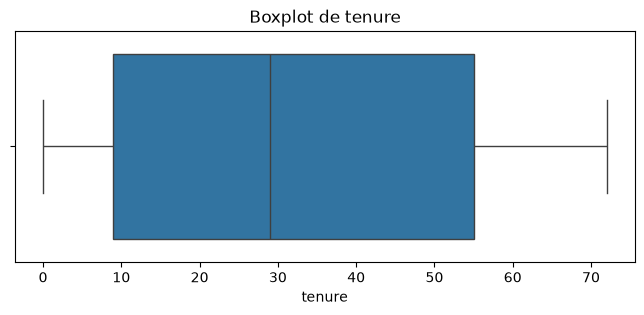

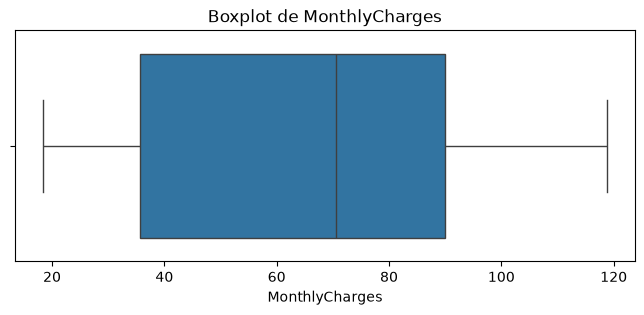

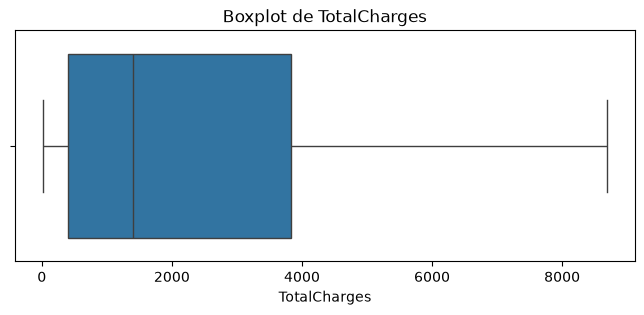

In [12]:
for col in numeric_features:

    plt.figure(figsize=(8, 3))

    sns.boxplot(
        x=X_train[col]
    )

    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)

    plt.show()

### 6.5. Détection des valeurs potentiellement aberrantes

La méthode de l'écart interquartile (IQR) est utilisée pour quantifier les
observations situées loin de la partie centrale de la distribution.

Les bornes utilisées sont :

- borne inférieure : Q1 - 1,5 × IQR ;
- borne supérieure : Q3 + 1,5 × IQR.

Les observations situées en dehors de ces bornes sont considérées comme
potentiellement aberrantes. Elles ne seront toutefois pas supprimées
automatiquement.

In [13]:
outlier_results = []

for col in numeric_features:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (X_train[col] < lower_bound) |
        (X_train[col] > upper_bound)
    )

    outlier_results.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Borne_inf": lower_bound,
        "Borne_sup": upper_bound,
        "Nb_outliers": outliers.sum(),
        "Pourcentage_outliers": outliers.mean() * 100
    })

outlier_df = pd.DataFrame(outlier_results)

outlier_df.round(2)

,Variable,Q1,Q3,IQR,Borne_inf,Borne_sup,Nb_outliers,Pourcentage_outliers
0,tenure,9.00,55.00,46.00,-60.00,124.00,0,0.0
1,MonthlyCharges,35.66,90.00,54.34,-45.84,171.51,0,0.0
2,TotalCharges,407.28,3838.61,3431.34,-4739.73,8985.62,0,0.0


### 6.6. Interprétation de la dispersion et des valeurs aberrantes

L'analyse des variables quantitatives de l'ensemble d'entraînement ne met en
évidence aucune valeur aberrante selon la méthode de l'écart interquartile
(IQR).

Pour `tenure`, aucune observation ne dépasse les bornes calculées. La moyenne
est de **32,49 mois** et la médiane de **29 mois**, ce qui indique une différence
relativement limitée entre ces deux mesures.

`MonthlyCharges` ne présente également aucune valeur aberrante selon la méthode
IQR. Sa moyenne est de **64,93** et sa médiane de **70,50**.

`TotalCharges` présente en revanche une différence importante entre sa moyenne
(**2 302,60**) et sa médiane (**1 398,12**). Son écart-type élevé
(**2 279,17**) et son boxplot montrent une distribution étendue vers les valeurs
élevées. Cependant, aucune observation ne dépasse les bornes IQR calculées.

Ainsi, aucune suppression de valeurs extrêmes n'est nécessaire sur la base de
ce critère. La distribution asymétrique de `TotalCharges` rend par ailleurs la
médiane particulièrement adaptée pour l'imputation de ses valeurs manquantes,
car elle est moins sensible aux valeurs élevées que la moyenne.

### 6.7. Analyse des valeurs manquantes

Après l'étude de la dispersion et des valeurs aberrantes, nous vérifions la
présence de valeurs manquantes dans les variables explicatives de l'ensemble
d'entraînement.

Cette vérification est réalisée sur `X_train` uniquement. Aucune imputation
n'est effectuée à ce stade.

L'objectif est d'identifier les variables concernées avant d'intégrer leur
traitement dans le pipeline de preprocessing.

In [14]:
missing_train = pd.DataFrame({
    "Nombre_manquant": X_train.isna().sum(),
    "Pourcentage": X_train.isna().mean() * 100
})

missing_train[
    missing_train["Nombre_manquant"] > 0
].round(2)

,Nombre_manquant,Pourcentage
TotalCharges,8,0.14


In [15]:
print("TotalCharges manquants dans le train :",
      X_train["TotalCharges"].isna().sum())

print("TotalCharges manquants dans le test :",
      X_test["TotalCharges"].isna().sum())

TotalCharges manquants dans le train : 8
TotalCharges manquants dans le test : 3


### Observation sur les valeurs manquantes

Après la séparation train/test, `TotalCharges` est la seule variable contenant
des valeurs manquantes.

L'ensemble d'entraînement contient **8 valeurs manquantes**, soit environ
**0,14 %** des observations du train, tandis que l'ensemble de test en contient
**3**. Nous retrouvons ainsi les **11 valeurs problématiques** identifiées lors
de l'analyse exploratoire.

Ces valeurs ne sont pas imputées manuellement. L'imputation sera intégrée dans
le pipeline afin que la médiane soit calculée uniquement à partir de
l'ensemble d'entraînement.

La même médiane apprise sur le train sera ensuite utilisée pour transformer
les données d'entraînement, de test et les futures observations.

## 6.8. Pipeline de préparation des variables numériques

Les variables numériques `tenure`, `MonthlyCharges` et `TotalCharges` sont
préparées à l'aide d'un pipeline composé de deux transformations.

La première étape utilise `SimpleImputer(strategy="median")` pour remplacer
les éventuelles valeurs manquantes par la médiane.

La seconde étape applique `StandardScaler` afin de standardiser les variables
numériques.

À ce stade, le pipeline est uniquement défini : aucune médiane, moyenne ou
écart-type n'est encore calculé. Ces paramètres seront appris ultérieurement
lors de l'entraînement du pipeline complet sur `X_train`.

In [16]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

## 6.9. Pipeline de préparation des variables catégorielles

Les variables catégorielles nécessitent un traitement différent des variables
numériques.

La variable `SeniorCitizen`, bien que stockée sous forme numérique, est
considérée comme catégorielle car ses valeurs `0` et `1` représentent deux
modalités.

Le sous-pipeline catégoriel comporte deux étapes :

1. les éventuelles valeurs manquantes sont remplacées par la modalité la plus
   fréquente avec `SimpleImputer(strategy="most_frequent")` ;
2. les catégories sont transformées en variables indicatrices avec
   `OneHotEncoder`.

L'option `handle_unknown="ignore"` permet de gérer une éventuelle modalité
présente dans de nouvelles données mais absente de l'ensemble d'entraînement.

Les modalités utilisées par l'imputation et l'encodage seront apprises
uniquement lors de l'entraînement du pipeline complet sur `X_train`.

In [17]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto ac

## 6.10. Regroupement des transformations avec `ColumnTransformer`

Les sous-pipelines numérique et catégoriel sont maintenant regroupés dans un
`ColumnTransformer`.

Le sous-pipeline numérique est appliqué aux variables `tenure`,
`MonthlyCharges` et `TotalCharges`. Il réalise l'imputation par la médiane,
puis la standardisation.

Le sous-pipeline catégoriel est appliqué aux variables catégorielles, y compris
`SeniorCitizen`. Il réalise l'imputation par la modalité la plus fréquente,
puis l'encodage One-Hot.

À ce stade, le `ColumnTransformer` est uniquement défini. Les paramètres des
transformations ne sont pas encore appris.

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 7. Baseline — Régression logistique

Après avoir défini le preprocessing numérique et catégoriel, nous ajoutons
une régression logistique afin de construire un pipeline unique.

Ce pipeline regroupe :

1. la préparation des variables numériques ;
2. la préparation des variables catégorielles ;
3. l'entraînement du modèle de régression logistique.

Cette approche garantit que toutes les transformations apprises sont ajustées
uniquement à partir des données d'entraînement.

La régression logistique constitue notre modèle de référence (*baseline*).
Ses performances serviront de point de comparaison pour évaluer l'intérêt
du feature engineering.

### 7.1. Construction du pipeline complet

Le `ColumnTransformer` précédemment défini est placé en première étape du
pipeline, suivi de la régression logistique.

Lors de l'entraînement, le preprocessing est d'abord ajusté sur `X_train`.
Les données transformées sont ensuite utilisées pour entraîner la régression
logistique.

In [19]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 7.2. Entraînement du pipeline

Le pipeline complet est entraîné sur `X_train` et `y_train`.

Lors de cet appel à `fit`, les différentes étapes apprennent successivement
leurs paramètres à partir des données d'entraînement uniquement :

- l'imputer numérique apprend les médianes ;
- `StandardScaler` apprend les moyennes et écarts-types ;
- l'imputer catégoriel apprend les modalités les plus fréquentes ;
- `OneHotEncoder` apprend les catégories présentes ;
- la régression logistique apprend finalement ses coefficients.

Aucune information provenant de `X_test` n'intervient dans cet apprentissage.

In [20]:
baseline_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

### 7.3. Prédiction sur l'ensemble de test

Après l'entraînement, le pipeline est utilisé pour prédire le statut de churn
des clients de l'ensemble de test.

Les transformations appliquées à `X_test` utilisent exclusivement les
paramètres précédemment appris sur `X_train`. Le pipeline n'est donc pas
réentraîné sur le jeu de test.

In [21]:
y_pred = baseline_pipeline.predict(X_test)

In [22]:
#les probabilités de churn, utiles notamment pour le ROC-AUC :
y_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

### 7.4. Évaluation de la baseline

Les performances de la régression logistique sont évaluées sur l'ensemble
de test, qui n'a pas été utilisé pour l'apprentissage.

Plusieurs métriques sont examinées afin d'obtenir une vision complète des
performances.

Une attention particulière est portée au **rappel de la classe Churn = Yes**,
car un faux négatif correspond à un client qui résilie sans avoir été identifié
comme client à risque.

Dans notre cadrage métier, le coût estimé d'un faux négatif est supérieur à
celui d'un faux positif. Le rappel constitue donc une métrique particulièrement
importante à surveiller.

In [23]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

roc_auc = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_proba
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.8055
Precision : 0.6572
Recall    : 0.5588
F1-score  : 0.6040
ROC-AUC   : 0.8419


In [24]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

          No     0.8488    0.8947    0.8711      1035
         Yes     0.6572    0.5588    0.6040       374

    accuracy                         0.8055      1409
   macro avg     0.7530    0.7268    0.7376      1409
weighted avg     0.7979    0.8055    0.8002      1409



In [25]:
confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

array([[926, 109],
       [165, 209]])

### 7.5. Interprétation et score de référence de la baseline

La régression logistique entraînée dans le pipeline constitue notre modèle
**baseline**.

Sur l'ensemble de test, elle obtient les performances suivantes :

- **Accuracy : 80,55 %**
- **Précision (Churn = Yes) : 65,72 %**
- **Recall (Churn = Yes) : 55,88 %**
- **F1-score (Churn = Yes) : 60,40 %**
- **ROC-AUC : 0,8419**

L'**accuracy de 80,55 %** constitue le score global de référence de cette
baseline. Le ROC-AUC de **0,8419** indique également une capacité satisfaisante
du modèle à distinguer les clients susceptibles de résilier des autres clients.

Cependant, les performances sur la classe `Churn = Yes` restent plus limitées.
Le modèle atteint un rappel de seulement **55,88 %**.

La matrice de confusion montre que, parmi les **374 clients ayant réellement
churné**, le modèle en détecte correctement **209**, mais en manque **165**.
Ces derniers constituent les faux négatifs.

À l'inverse, **109 clients n'ayant pas churné** sont classés à tort comme
clients à risque et constituent les faux positifs.

Compte tenu du cadrage métier, dans lequel le coût d'un faux négatif est estimé
à **300** contre **50** pour un faux positif, les faux négatifs sont
particulièrement pénalisants. Le **recall de 55,88 %** constitue donc une
métrique importante à améliorer, en complément du score global.

Les performances de cette baseline constituent désormais les **valeurs de
référence à battre**. Le feature engineering sera conservé uniquement s'il
apporte une amélioration réelle des performances, notamment de la capacité
à détecter les clients susceptibles de churner.

### 7.6. Coût métier de la baseline

En complément des métriques classiques, nous calculons le coût des erreurs
selon les hypothèses définies lors du cadrage :

- faux négatif (FN) : **300** ;
- faux positif (FP) : **50**.

La fonction de coût utilisée est :

**Coût = 300 × FN + 50 × FP**

Pour la baseline, nous obtenons **165 faux négatifs** et **109 faux positifs**,
soit un coût total estimé à :

**(165 × 300) + (109 × 50) = 54 950**

Cette valeur constitue une référence métier supplémentaire. Une amélioration
du modèle sera particulièrement intéressante si elle permet de réduire ce coût.

In [26]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
).ravel()

cost_fn = 300
cost_fp = 50

business_cost = fn * cost_fn + fp * cost_fp

print("TN :", tn)
print("FP :", fp)
print("FN :", fn)
print("TP :", tp)

print("\nCoût métier :", business_cost)

TN : 926
FP : 109
FN : 165
TP : 209

Coût métier : 54950


## 8. Feature engineering

L'objectif du feature engineering est de créer de nouvelles variables
susceptibles d'améliorer la capacité du modèle à identifier les clients
à risque de churn.

Trois nouvelles caractéristiques seront étudiées :

1. une catégorisation de l'ancienneté du client ;
2. le nombre de services souscrits ;
3. un ratio entre les charges et l'ancienneté.

Chaque feature sera évaluée séparément en validation croisée sur l'ensemble
d'entraînement.

Une feature ne sera conservée que si elle apporte une amélioration réelle
des performances par rapport à la baseline. Dans le cas contraire, elle sera
supprimée afin de conserver un modèle aussi simple que possible, conformément
au principe du rasoir d'Occam.

L'ensemble de test n'est pas utilisé pour sélectionner les nouvelles features.

### 8.1. Évaluation de la baseline en validation croisée

Avant d'ajouter de nouvelles variables, nous évaluons la régression logistique
baseline par validation croisée stratifiée à 5 folds sur l'ensemble
d'entraînement.

Cette étape fournit une référence plus robuste pour comparer les différentes
propositions de feature engineering.

La stratification permet de conserver approximativement la proportion de
churn dans chaque fold.

L'ensemble de test reste totalement exclu de cette phase de sélection.

In [27]:
from sklearn.metrics import make_scorer

scoring = {
    "accuracy": "accuracy",

    "recall": make_scorer(
        recall_score,
        pos_label="Yes"
    ),

    "f1": make_scorer(
        f1_score,
        pos_label="Yes"
    ),

    "roc_auc": "roc_auc"
}

In [28]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "recall": make_scorer(
        recall_score,
        pos_label="Yes"
    ),
    "f1": make_scorer(
        f1_score,
        pos_label="Yes"
    ),
    "roc_auc": "roc_auc"
}

In [29]:
cv_baseline = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [30]:
baseline_cv_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Moyenne_CV": [
        cv_baseline["test_accuracy"].mean(),
        cv_baseline["test_recall"].mean(),
        cv_baseline["test_f1"].mean(),
        cv_baseline["test_roc_auc"].mean()
    ],
    "Écart_type": [
        cv_baseline["test_accuracy"].std(),
        cv_baseline["test_recall"].std(),
        cv_baseline["test_f1"].std(),
        cv_baseline["test_roc_auc"].std()
    ]
})

baseline_cv_results.round(4)

,Métrique,Moyenne_CV,Écart_type
0,Accuracy,0.8026,0.0120
1,Recall,0.5431,0.0411
2,F1-score,0.5930,0.0298
3,ROC-AUC,0.8461,0.0125


### 8.2. Interprétation de la baseline en validation croisée

La validation croisée stratifiée à 5 folds donne une accuracy moyenne de
**80,26 %**, avec un écart-type de **1,20 %**, ce qui indique une performance
relativement stable entre les folds.

Pour la classe `Churn = Yes`, le recall moyen est de **54,31 %** et le
F1-score moyen de **59,30 %**.

Le ROC-AUC moyen atteint **0,8461**, avec un faible écart-type de **0,0125**.

Ces résultats constituent désormais la référence de validation croisée pour
évaluer les nouvelles features. Une feature ne sera conservée que si elle
apporte une amélioration suffisamment pertinente par rapport à cette baseline,
en accordant une attention particulière au recall et au F1-score.

### 8.3. Feature 1 — Catégorisation de l'ancienneté

L'analyse exploratoire a montré que l'ancienneté (`tenure`) est fortement
associée au churn : les clients ayant résilié présentent notamment une
ancienneté médiane beaucoup plus faible.

Nous créons donc une nouvelle variable catégorielle `tenure_group` afin de
représenter différentes phases de la relation client :

- `0-12 mois` ;
- `13-24 mois` ;
- `25-48 mois` ;
- `49-72 mois`.

La variable numérique `tenure` originale est conservée. La nouvelle feature
apporte une représentation complémentaire permettant au modèle de capturer
plus facilement d'éventuels changements de comportement entre différentes
périodes d'ancienneté.

Son intérêt sera vérifié par validation croisée avant de décider de la
conserver.

In [31]:
X_train_fe1 = X_train.copy()
X_test_fe1 = X_test.copy()

In [32]:
X_train_fe1["tenure_group"] = pd.cut(
    X_train_fe1["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12",
        "13-24",
        "25-48",
        "49-72"
    ]
)

X_test_fe1["tenure_group"] = pd.cut(
    X_test_fe1["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12",
        "13-24",
        "25-48",
        "49-72"
    ]
)

In [33]:
X_train_fe1["tenure_group"].value_counts().sort_index()


tenure_group
0-12     1737
13-24     818
25-48    1290
49-72    1789
Name: count, dtype: int64

In [34]:
categorical_features_fe1 = categorical_features + [
    "tenure_group"
]

In [35]:
numeric_features_fe1 = numeric_features.copy()

In [36]:
preprocessor_fe1 = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features_fe1
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features_fe1
        )
    ]
)

In [37]:
pipeline_fe1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe1),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [38]:
cv_fe1 = cross_validate(
    pipeline_fe1,
    X_train_fe1,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [39]:
fe1_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Baseline": [
        cv_baseline["test_accuracy"].mean(),
        cv_baseline["test_recall"].mean(),
        cv_baseline["test_f1"].mean(),
        cv_baseline["test_roc_auc"].mean()
    ],
    "Avec_tenure_group": [
        cv_fe1["test_accuracy"].mean(),
        cv_fe1["test_recall"].mean(),
        cv_fe1["test_f1"].mean(),
        cv_fe1["test_roc_auc"].mean()
    ]
})

fe1_results["Gain"] = (
    fe1_results["Avec_tenure_group"]
    - fe1_results["Baseline"]
)

fe1_results.round(4)

,Métrique,Baseline,Avec_tenure_group,Gain
0,Accuracy,0.8026,0.8058,0.0032
1,Recall,0.5431,0.5358,-0.0074
2,F1-score,0.5930,0.5936,0.0006
3,ROC-AUC,0.8461,0.8464,0.0003


#### Conclusion — Feature `tenure_group`

L'ajout de la variable `tenure_group` améliore légèrement l'accuracy, qui passe
de **80,26 % à 80,58 %**, soit un gain de **0,32 point de pourcentage**.

Le F1-score et le ROC-AUC restent pratiquement inchangés, avec des gains
respectifs de seulement **0,0006** et **0,0003**.

En revanche, le recall de la classe `Churn = Yes` diminue de **54,31 % à
53,58 %**, soit une baisse de **0,74 point de pourcentage**.

Cette évolution est défavorable au regard de notre objectif métier, qui accorde
une importance particulière à la détection des clients susceptibles de churner.

La variable `tenure_group` n'apporte donc pas d'amélioration suffisamment
pertinente par rapport à la baseline. Conformément au principe du rasoir
d'Occam, elle n'est pas retenue pour la suite.

### 8.4. Feature 2 — Nombre de services souscrits

Plusieurs variables du dataset indiquent si un client utilise différents
services télécom et Internet.

L'analyse exploratoire a notamment montré que certaines variables liées aux
services, telles que `OnlineSecurity` et `TechSupport`, sont associées au churn.

Nous créons donc une nouvelle variable `NumServices` représentant le nombre
total de services effectivement souscrits par chaque client.

Les services considérés sont :

- `PhoneService` ;
- `MultipleLines` ;
- `OnlineSecurity` ;
- `OnlineBackup` ;
- `DeviceProtection` ;
- `TechSupport` ;
- `StreamingTV` ;
- `StreamingMovies`.

Cette nouvelle variable vise à représenter le niveau global d'équipement ou
d'engagement du client.

Son intérêt sera évalué par validation croisée avant de décider de la conserver.

In [40]:
X_train_fe2 = X_train.copy()
X_test_fe2 = X_test.copy()

service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]


In [41]:
X_train_fe2["NumServices"] = (
    X_train_fe2[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

X_test_fe2["NumServices"] = (
    X_test_fe2[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

In [42]:
X_train_fe2[
    service_cols + ["NumServices"]
].head()

,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,NumServices
3738,No,No phone service,No,No,Yes,No,Yes,Yes,3
3151,Yes,No,Yes,No,No,No,No,No,2
4860,No,No phone service,Yes,Yes,No,Yes,No,No,3
3867,Yes,No,No,Yes,Yes,No,Yes,Yes,5
3810,Yes,No,No,No,No,No,No,No,1


In [43]:
X_train_fe2["NumServices"].value_counts().sort_index()

NumServices
0      63
1    1360
2     924
3     777
4     741
5     724
6     552
7     319
8     174
Name: count, dtype: int64

In [44]:
X_train_fe2["NumServices"].describe()

count    5634.000000
mean        3.383032
std         2.071139
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: NumServices, dtype: float64

In [45]:
numeric_features_fe2 = numeric_features + [
    "NumServices"
]

categorical_features_fe2 = categorical_features.copy()

In [46]:
preprocessor_fe2 = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features_fe2
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features_fe2
        )
    ]
)

In [47]:
pipeline_fe2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe2),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [48]:
cv_fe2 = cross_validate(
    pipeline_fe2,
    X_train_fe2,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [49]:
fe2_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Baseline": [
        cv_baseline["test_accuracy"].mean(),
        cv_baseline["test_recall"].mean(),
        cv_baseline["test_f1"].mean(),
        cv_baseline["test_roc_auc"].mean()
    ],

    "Avec_NumServices": [
        cv_fe2["test_accuracy"].mean(),
        cv_fe2["test_recall"].mean(),
        cv_fe2["test_f1"].mean(),
        cv_fe2["test_roc_auc"].mean()
    ]
})

fe2_results["Gain"] = (
    fe2_results["Avec_NumServices"]
    - fe2_results["Baseline"]
)

fe2_results.round(4)

,Métrique,Baseline,Avec_NumServices,Gain
0,Accuracy,0.8026,0.8019,-0.0007
1,Recall,0.5431,0.5431,0.0000
2,F1-score,0.5930,0.5921,-0.0009
3,ROC-AUC,0.8461,0.8462,0.0001


#### Conclusion — Feature `NumServices`

L'ajout de la variable `NumServices` n'améliore pas réellement les performances
de la régression logistique en validation croisée.

L'accuracy diminue légèrement de **80,26 % à 80,19 %**, tandis que le recall
reste inchangé à **54,31 %**. Le F1-score diminue également légèrement, passant
de **0,5930 à 0,5921**.

Le ROC-AUC augmente de seulement **0,8461 à 0,8462**, soit un gain de **0,0001**,
qui est trop faible pour justifier l'ajout d'une nouvelle variable.

`NumServices` ne fournit donc pas d'amélioration suffisamment pertinente par
rapport à la baseline. Conformément au principe du rasoir d'Occam, cette
feature n'est pas retenue.

### 8.5. Feature 3 — Ratio charges / ancienneté

La troisième feature étudiée vise à mettre en relation les charges cumulées
du client avec son ancienneté.

Nous créons une variable `ChargesPerTenure` correspondant au rapport entre
`TotalCharges` et `tenure`.

Cette variable cherche à représenter le niveau de charges cumulées relativement
à la durée de la relation du client avec l'entreprise.

Les clients ayant une ancienneté nulle nécessitent un traitement particulier
afin d'éviter une division par zéro.

Comme pour les features précédentes, cette nouvelle variable sera évaluée
séparément en validation croisée avant de décider de sa conservation.

In [50]:
X_train_fe3 = X_train.copy()
X_test_fe3 = X_test.copy()


In [51]:
X_train_fe3["ChargesPerTenure"] = (
    X_train_fe3["TotalCharges"]
    / X_train_fe3["tenure"].replace(0, np.nan)
)

X_test_fe3["ChargesPerTenure"] = (
    X_test_fe3["TotalCharges"]
    / X_test_fe3["tenure"].replace(0, np.nan)
)

In [52]:
X_train_fe3[
    ["TotalCharges", "tenure", "ChargesPerTenure"]
].head(10)

,TotalCharges,tenure,ChargesPerTenure
3738,1701.65,35,48.618571
3151,1151.55,15,76.770000
4860,590.35,13,45.411538
3867,1905.70,26,73.296154
3810,44.55,1,44.550000
2666,5196.10,66,78.728788
2645,19.80,1,19.800000
189,2379.10,40,59.477500
5767,3808.20,65,58.587692
2257,4847.05,60,80.784167


In [53]:
numeric_features_fe3 = numeric_features + [
    "ChargesPerTenure"
]

categorical_features_fe3 = categorical_features.copy()

In [54]:
preprocessor_fe3 = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features_fe3
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features_fe3
        )
    ]
)

In [55]:
pipeline_fe3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe3),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [56]:
cv_fe3 = cross_validate(
    pipeline_fe3,
    X_train_fe3,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [57]:
fe3_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Baseline": [
        cv_baseline["test_accuracy"].mean(),
        cv_baseline["test_recall"].mean(),
        cv_baseline["test_f1"].mean(),
        cv_baseline["test_roc_auc"].mean()
    ],

    "Avec_ChargesPerTenure": [
        cv_fe3["test_accuracy"].mean(),
        cv_fe3["test_recall"].mean(),
        cv_fe3["test_f1"].mean(),
        cv_fe3["test_roc_auc"].mean()
    ]
})

fe3_results["Gain"] = (
    fe3_results["Avec_ChargesPerTenure"]
    - fe3_results["Baseline"]
)

fe3_results.round(4)

,Métrique,Baseline,Avec_ChargesPerTenure,Gain
0,Accuracy,0.8026,0.8021,-0.0005
1,Recall,0.5431,0.5452,0.0020
2,F1-score,0.5930,0.5932,0.0002
3,ROC-AUC,0.8461,0.8457,-0.0004


#### Conclusion — Feature `ChargesPerTenure`

L'ajout de la variable `ChargesPerTenure` entraîne une légère amélioration du
recall, qui passe de **54,31 % à 54,52 %**, soit un gain de seulement
**0,20 point de pourcentage**.

Le F1-score reste pratiquement stable, passant de **0,5930 à 0,5932**.
En revanche, l'accuracy diminue légèrement de **80,26 % à 80,21 %** et le
ROC-AUC passe de **0,8461 à 0,8457**.

Le gain observé sur le recall reste très faible par rapport à la variabilité
observée en validation croisée. Cette feature n'apporte donc pas une
amélioration suffisamment importante et stable pour justifier sa conservation.

Conformément au principe du rasoir d'Occam, `ChargesPerTenure` n'est pas
retenue dans le pipeline final.

### 8.6. Bilan du feature engineering

Trois nouvelles features ont été évaluées séparément en validation croisée
stratifiée à 5 folds et comparées à la régression logistique baseline.

| Feature | Accuracy | Recall | F1-score | ROC-AUC | Décision |
|---|---:|---:|---:|---:|---|
| Baseline | 0,8026 | 0,5431 | 0,5930 | 0,8461 | Référence |
| `tenure_group` | 0,8058 | 0,5358 | 0,5936 | 0,8464 | Rejetée |
| `NumServices` | 0,8019 | 0,5431 | 0,5921 | 0,8462 | Rejetée |
| `ChargesPerTenure` | 0,8021 | 0,5452 | 0,5932 | 0,8457 | Rejetée |

`tenure_group` améliore légèrement l'accuracy, mais réduit le recall, qui est
une métrique importante dans notre contexte métier.

`NumServices` n'apporte pratiquement aucune amélioration et dégrade légèrement
l'accuracy et le F1-score.

`ChargesPerTenure` améliore légèrement le recall, mais le gain de **0,0020**
reste très faible, tandis que l'accuracy et le ROC-AUC diminuent légèrement.

Aucune des trois nouvelles features ne produit donc une amélioration
suffisamment importante et cohérente des performances en validation croisée.

Conformément au principe du **rasoir d'Occam**, ces features ne sont pas
retenues. Le pipeline baseline, plus simple, est conservé comme pipeline final
de cette mission.

### 8.7. Feature 4 — Présence d'un service de protection

L'analyse exploratoire a montré que `OnlineSecurity` et `TechSupport` font
partie des variables les plus discriminantes vis-à-vis du churn.

Les clients ne disposant pas de ces services présentaient également un taux
de churn nettement supérieur aux clients qui en disposent.

Nous créons donc une variable `HasProtection` indiquant si le client dispose
d'au moins l'un des deux services suivants :

- sécurité en ligne (`OnlineSecurity`) ;
- support technique (`TechSupport`).

Cette feature cherche à représenter simplement le niveau de protection et
d'accompagnement du client.

Son intérêt sera évalué avec la même validation croisée que la baseline.

In [58]:
X_train_fe4 = X_train.copy()
X_test_fe4 = X_test.copy()

X_train_fe4["HasProtection"] = np.where(
    (X_train_fe4["OnlineSecurity"] == "Yes") |
    (X_train_fe4["TechSupport"] == "Yes"),
    "Yes",
    "No"
)

X_test_fe4["HasProtection"] = np.where(
    (X_test_fe4["OnlineSecurity"] == "Yes") |
    (X_test_fe4["TechSupport"] == "Yes"),
    "Yes",
    "No"
)

In [59]:
X_train_fe4["HasProtection"].value_counts()

HasProtection
No     3248
Yes    2386
Name: count, dtype: int64

In [60]:
pd.crosstab(
    X_train_fe4["HasProtection"],
    y_train,
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
HasProtection,,
No,66.50,33.50
Yes,82.94,17.06


In [61]:
numeric_features_fe4 = numeric_features.copy()

categorical_features_fe4 = (
    categorical_features + ["HasProtection"]
)

In [62]:
preprocessor_fe4 = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features_fe4),
        ("cat", categorical_pipeline, categorical_features_fe4)
    ]
)

pipeline_fe4 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe4),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [63]:
cv_fe4 = cross_validate(
    pipeline_fe4,
    X_train_fe4,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


In [64]:
fe4_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Baseline": [
        cv_baseline["test_accuracy"].mean(),
        cv_baseline["test_recall"].mean(),
        cv_baseline["test_f1"].mean(),
        cv_baseline["test_roc_auc"].mean()
    ],

    "Avec_HasProtection": [
        cv_fe4["test_accuracy"].mean(),
        cv_fe4["test_recall"].mean(),
        cv_fe4["test_f1"].mean(),
        cv_fe4["test_roc_auc"].mean()
    ]
})

fe4_results["Gain"] = (
    fe4_results["Avec_HasProtection"]
    - fe4_results["Baseline"]
)

fe4_results.round(4)


,Métrique,Baseline,Avec_HasProtection,Gain
0,Accuracy,0.8026,0.8028,0.0002
1,Recall,0.5431,0.5445,0.0013
2,F1-score,0.5930,0.5936,0.0006
3,ROC-AUC,0.8461,0.8459,-0.0003


#### Conclusion — Feature `HasProtection`

L'ajout de `HasProtection` entraîne une très légère amélioration de l'accuracy,
du recall et du F1-score.

Le recall passe de **54,31 % à 54,45 %**, soit un gain de seulement
**0,13 point de pourcentage**. Le F1-score augmente de **0,0006** et
l'accuracy de **0,0002**.

En revanche, le ROC-AUC diminue légèrement de **0,8461 à 0,8459**.

Ces variations restent très faibles par rapport à la variabilité observée en
validation croisée. La feature `HasProtection` n'apporte donc pas une
amélioration suffisamment importante pour justifier sa conservation.

Conformément au principe du rasoir d'Occam, elle est rejetée.

### 8.8. Feature 5 — Interaction entre contrat mensuel et fibre optique

L'analyse exploratoire a montré que les clients avec un contrat
`Month-to-month` présentent un taux de churn élevé (**42,71 %**).

De même, les clients utilisant `Fiber optic` présentent un taux de churn
de **41,89 %**.

Nous créons donc une variable binaire `MonthlyFiber` permettant d'identifier
les clients qui cumulent ces deux caractéristiques.

Cette interaction peut permettre à la régression logistique de représenter
explicitement l'effet combiné du contrat mensuel et de la fibre optique.

Comme pour les features précédentes, son intérêt sera évalué par validation
croisée avant de décider de sa conservation.

In [65]:
X_train_fe5 = X_train.copy()
X_test_fe5 = X_test.copy()

X_train_fe5["MonthlyFiber"] = np.where(
    (X_train_fe5["Contract"] == "Month-to-month") &
    (X_train_fe5["InternetService"] == "Fiber optic"),
    "Yes",
    "No"
)

X_test_fe5["MonthlyFiber"] = np.where(
    (X_test_fe5["Contract"] == "Month-to-month") &
    (X_test_fe5["InternetService"] == "Fiber optic"),
    "Yes",
    "No"
)

In [66]:
X_train_fe5["MonthlyFiber"].value_counts()

MonthlyFiber
No     3927
Yes    1707
Name: count, dtype: int64

In [67]:
pd.crosstab(
    X_train_fe5["MonthlyFiber"],
    y_train,
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
MonthlyFiber,,
No,85.87,14.13
Yes,44.93,55.07


In [68]:
numeric_features_fe5 = numeric_features.copy()

categorical_features_fe5 = (
    categorical_features + ["MonthlyFiber"]
)

In [69]:
preprocessor_fe5 = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features_fe5
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features_fe5
        )
    ]
)

In [70]:
pipeline_fe5 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe5),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [71]:
cv_fe5 = cross_validate(
    pipeline_fe5,
    X_train_fe5,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [72]:
fe5_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Baseline": [
        cv_baseline["test_accuracy"].mean(),
        cv_baseline["test_recall"].mean(),
        cv_baseline["test_f1"].mean(),
        cv_baseline["test_roc_auc"].mean()
    ],

    "Avec_MonthlyFiber": [
        cv_fe5["test_accuracy"].mean(),
        cv_fe5["test_recall"].mean(),
        cv_fe5["test_f1"].mean(),
        cv_fe5["test_roc_auc"].mean()
    ]
})

fe5_results["Gain"] = (
    fe5_results["Avec_MonthlyFiber"]
    - fe5_results["Baseline"]
)

fe5_results.round(4)

,Métrique,Baseline,Avec_MonthlyFiber,Gain
0,Accuracy,0.8026,0.8025,-0.0002
1,Recall,0.5431,0.5438,0.0007
2,F1-score,0.5930,0.5930,0.0000
3,ROC-AUC,0.8461,0.8460,-0.0001


### 8.9. Comparaison finale du feature engineering

Afin d'évaluer l'intérêt du feature engineering, chaque nouvelle variable a
été testée séparément avec la même validation croisée stratifiée à 5 folds.

Les performances obtenues sont comparées à celles de la régression logistique
baseline.

| Modèle / Feature | Accuracy | Recall | F1-score | ROC-AUC | Décision |
|---|---:|---:|---:|---:|---|
| Baseline | **0,8026** | 0,5431 | 0,5930 | **0,8461** | Retenue |
| + `tenure_group` | 0,8058 | 0,5358 | 0,5936 | 0,8464 | Rejetée |
| + `NumServices` | 0,8019 | 0,5431 | 0,5921 | 0,8462 | Rejetée |
| + `ChargesPerTenure` | 0,8021 | **0,5452** | 0,5932 | 0,8457 | Rejetée |
| + `HasProtection` | 0,8028 | 0,5445 | **0,5936** | 0,8459 | Rejetée |
| + `MonthlyFiber` | 0,8025 | 0,5438 | 0,5930 | 0,8460 | Rejetée |

Certaines nouvelles variables entraînent de légères variations des métriques,
mais aucune ne produit une amélioration suffisamment importante et cohérente
pour justifier une augmentation de la complexité du modèle.

`tenure_group` améliore notamment l'accuracy mais réduit le recall.
`ChargesPerTenure` obtient le meilleur recall (**54,52 %**), mais le gain par
rapport à la baseline (**54,31 %**) reste très faible et s'accompagne d'une
légère diminution de l'accuracy et du ROC-AUC.

Conformément au principe du rasoir d'Occam, aucune des nouvelles features
testées n'est retenue. La régression logistique baseline, utilisant les
variables originales, est conservée comme solution finale de cette mission.

## 9. Pipeline final retenu

À l'issue des expérimentations, le pipeline baseline est conservé.

Il réalise automatiquement :

- pour les variables numériques :
  - imputation par la médiane ;
  - standardisation avec `StandardScaler` ;

- pour les variables catégorielles :
  - imputation par la modalité la plus fréquente ;
  - encodage avec `OneHotEncoder` ;

- puis l'entraînement d'une régression logistique.

La variable `SeniorCitizen` est traitée comme catégorielle malgré son stockage
numérique, car ses valeurs 0 et 1 représentent deux modalités.

Toutes les transformations apprises sont ajustées uniquement sur les données
d'entraînement, ce qui évite toute fuite d'information depuis le jeu de test.

Les features supplémentaires testées n'ayant pas apporté d'amélioration
significative en validation croisée, elles ne sont pas intégrées au pipeline
final.

In [73]:
final_pipeline = baseline_pipeline

In [74]:
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

## 10. Conclusion de la Mission 2

La préparation des données a été réalisée en respectant le principe fondamental
de séparation entre apprentissage et évaluation.

Le dataset a d'abord été séparé en ensembles d'entraînement (**80 %**) et de
test (**20 %**) avec stratification sur la variable `Churn`.

Toutes les transformations apprises ont ensuite été intégrées dans un pipeline
scikit-learn. Les variables numériques sont imputées par la médiane puis
standardisées, tandis que les variables catégorielles sont imputées par leur
modalité la plus fréquente puis encodées par One-Hot Encoding.

Une régression logistique a été utilisée comme baseline. Sur le jeu de test,
elle obtient une accuracy de **80,55 %**, un recall de **55,88 %**, un F1-score
de **60,40 %** et un ROC-AUC de **0,8419**.

En validation croisée stratifiée à 5 folds sur l'ensemble d'entraînement, la
baseline obtient une accuracy moyenne de **80,26 %**, un recall de **54,31 %**,
un F1-score de **59,30 %** et un ROC-AUC de **0,8461**.

Plusieurs features supplémentaires ont été évaluées : catégorisation de
l'ancienneté, nombre de services, ratio charges/ancienneté, présence de services
de protection et interaction contrat mensuel/fibre optique.

Aucune n'a apporté une amélioration suffisamment importante et cohérente des
performances en validation croisée. Elles ont donc été rejetées conformément
au principe du rasoir d'Occam.

Le pipeline baseline est ainsi conservé comme pipeline final reproductible de
la Mission 2.